# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama              | NRP        |
|-------------------|------------|
| Lioneil Diyoel Trystan Tikupadang | 5054251037 |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, dll) 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix


In [13]:
#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.

data = pd.read_csv('WineQT.csv')
data.head()
data.info()
data.describe()

! Cari fungsi-fungsi yang dapat digunakan untuk menampilkan informasi yang diinginkan. 

print("Shape dataset:", data.shape)
print("\nMissing values per kolom:")
print(data.isnull().sum())
print("\nJumlah duplikasi:", data.duplicated().sum())

# Id sebagai identifier
target_column = "quality"
drop_columns = ["quality", "Id"]
X = data.drop(columns=drop_columns)
y = data[target_column]

print("\nDistribusi target quality:")
print(y.value_counts().sort_index())


<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
Shape dataset: (1143, 13)

Missing values per kolom:
fixed acidity           0
volatil

'Cari' is not recognized as an internal or external command,
operable program or batch file.


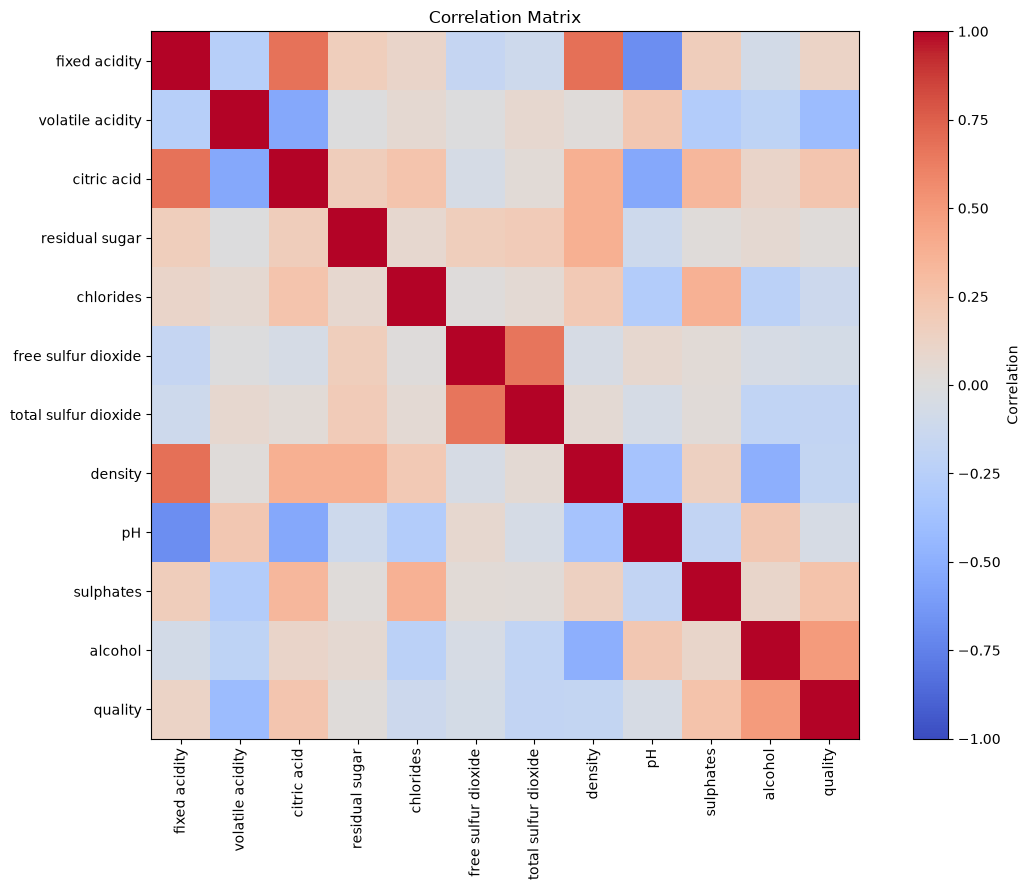

In [ ]:
# Tampilkan Korelasi Matrix

corr = data.drop(columns=["Id"]).corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()


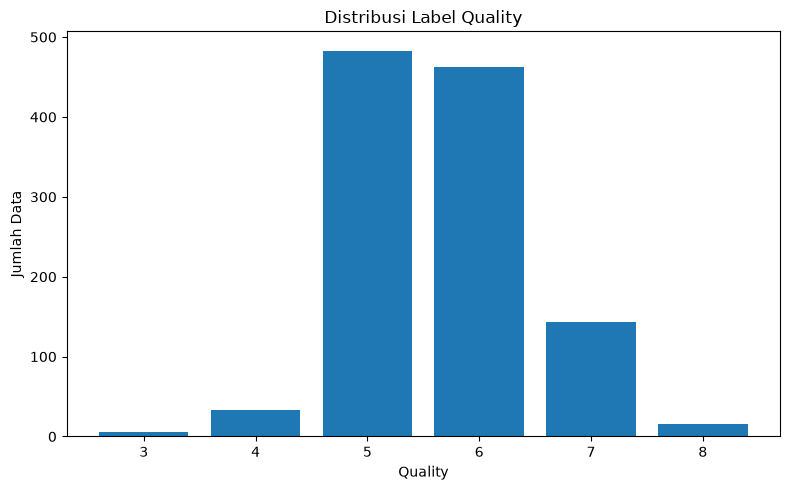

In [17]:
# Tampilkan distribusi label (quality) dalam bentuk visualisasi, misalnya menggunakan histogram atau bar plot.

quality_counts = data["quality"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(quality_counts.index.astype(str), quality_counts.values)
plt.xlabel("Quality")
plt.ylabel("Jumlah Data")
plt.title("Distribusi Label Quality")
plt.tight_layout()
plt.show()


## Silahkan Lakukan Exploratory Data Analysis (EDA) tambahan yang dibutuhkan. 

### Tambahan EDA
Untuk memahami karakteristik data sebelum modeling, saya menambahkan analisis statistik sederhana berupa rata-rata setiap fitur berdasarkan nilai `quality`. Analisis ini digunakan untuk melihat apakah terdapat pola perubahan fitur terhadap kualitas wine.

```python
feature_means_by_quality = data.groupby("quality")[X.columns].mean()
display(feature_means_by_quality.round(3))
```

Hasilnya digunakan sebagai eksplorasi awal dan tidak langsung dianggap sebagai bukti hubungan sebab-akibat.


# 2. Preprocessing




In [18]:
# NaN handling (drop, impute, etc.), duplicate handling, dan lain-lain.

print("Jumlah missing value sebelum handling:", data.isnull().sum().sum())
print("Jumlah duplicate sebelum handling:", data.duplicated().sum())

data_clean = data.drop_duplicates().copy()
print("Jumlah baris setelah duplicate handling:", len(data_clean))


Jumlah missing value sebelum handling: 0
Jumlah duplicate sebelum handling: 0
Jumlah baris setelah duplicate handling: 1143


Jumlah data yang memiliki outlier pada minimal satu fitur: 295


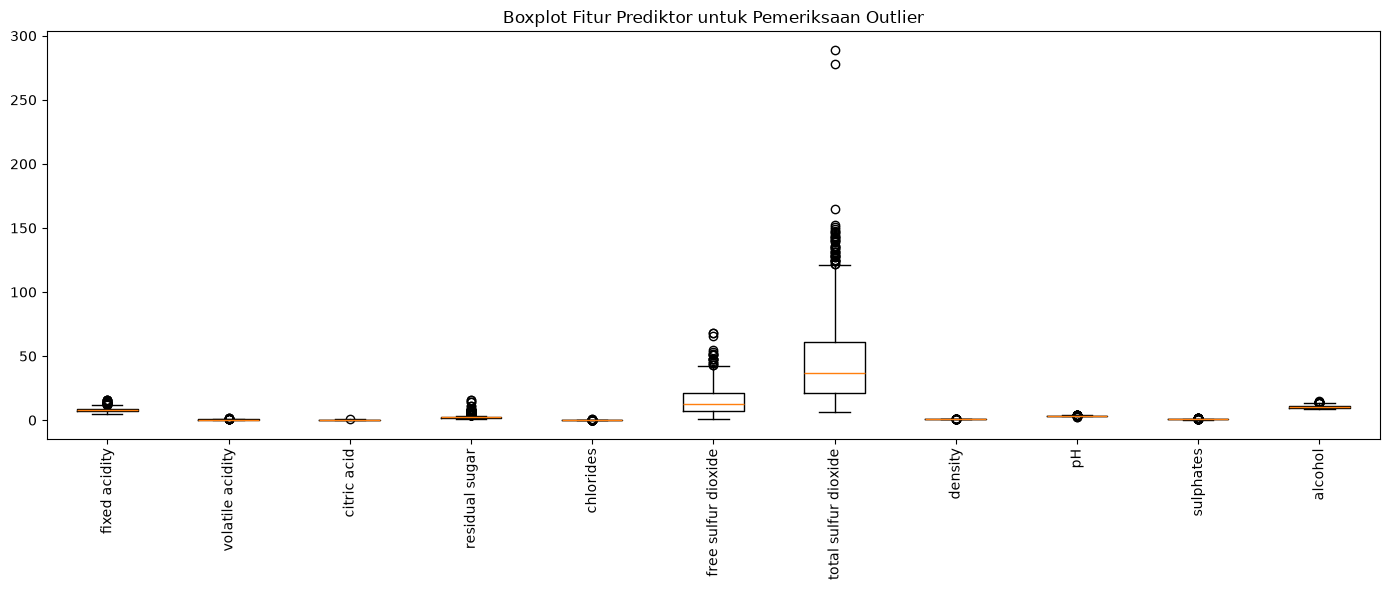

Outlier tidak langsung dihapus. Pengaruh penghapusan outlier akan diuji sebagai eksperimen tambahan pada data train.


In [23]:
# Periksa Outliers (jika diperlukan), misalnya menggunakan boxplot atau metode statistik lainnya. (Bisa dilakukan eksperimen dengan dan tanpa outlier untuk melihat perbedaan performa model)

Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = ((X < lower_bound) | (X > upper_bound)).any(axis=1)
print("Jumlah data yang memiliki outlier pada minimal satu fitur:", int(outlier_mask.sum()))

plt.figure(figsize=(14, 6))
plt.boxplot(X.values, tick_labels=X.columns, showfliers=True)
plt.xticks(rotation=90)
plt.title("Boxplot Fitur Prediktor untuk Pemeriksaan Outlier")
plt.tight_layout()
plt.show()

print("Outlier tidak langsung dihapus. Pengaruh penghapusan outlier akan diuji sebagai eksperimen tambahan pada data train.")


In [26]:
# Scaling data (jika diperlukan), misalnya menggunakan StandardScaler atau MinMaxScaler. (Bisa dilakukan eksperimen dengan dan tanpa scaling untuk melihat perbedaan performa model)
# Perhatikan data leakage saat melakukan scaling. Scaling harus dilakukan setelah membagi data menjadi train dan test set.


# 3. Eksperimen Model KNN


In [28]:
# Split data menjadi train dan test set. (misal 80% train, 20% test)
# Gunakan fungsi train_test_split dari sklearn.model_selection untuk membagi data menjadi train dan test set. Pastikan untuk memisahkan fitur (X) dan label (y) sebelum melakukan split.
# Gunakan stratify=y agar distribusi label pada train dan test set tetap sama dengan distribusi label pada dataset asli.
# Train model KNN menggunakan train set. Gunakan fungsi KNeighborsClassifier dari sklearn.neighbors untuk membuat model KNN. Lakukan eksperimen dengan berbagai nilai k (misal k=1, 3, 5, 7, 9) dan catat performa model pada train set dan test set.

# Fitur dan target terpisah.
X = data_clean.drop(columns=["quality", "Id"])
y = data_clean["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_values = [1, 3, 5, 7, 9]
metrics_to_test = [("Euclidean", 2), ("Manhattan", 1)]
results = []

# Eksperimen tanpa scaling dan dengan scaling.
for scaling_name, Xtr, Xte in [
    ("Tanpa Scaling", X_train.values, X_test.values),
    ("StandardScaler", X_train_scaled, X_test_scaled)
]:
    for metric_name, p_value in metrics_to_test:
        for k in k_values:
            knn = KNeighborsClassifier(
                n_neighbors=k,
                weights="uniform",
                metric="minkowski",
                p=p_value
            )
            knn.fit(Xtr, y_train)

            pred_train = knn.predict(Xtr)
            pred_test = knn.predict(Xte)

            results.append({
                "Scaling": scaling_name,
                "Metric": metric_name,
                "k": k,
                "Train Accuracy": accuracy_score(y_train, pred_train),
                "Test Accuracy": accuracy_score(y_test, pred_test),
                "Test Precision": precision_score(y_test, pred_test, average="weighted", zero_division=0),
                "Test Recall": recall_score(y_test, pred_test, average="weighted", zero_division=0),
                "Test F1": f1_score(y_test, pred_test, average="weighted", zero_division=0)
            })

results_df = pd.DataFrame(results).sort_values(
    by=["Test F1", "Test Accuracy"], ascending=False
).reset_index(drop=True)

print("Hasil seluruh eksperimen:")
display(results_df.round(4))

# Eksperimen tambahan lagi
Q1_train = X_train.quantile(0.25)
Q3_train = X_train.quantile(0.75)
IQR_train = Q3_train - Q1_train
lower_train = Q1_train - 1.5 * IQR_train
upper_train = Q3_train + 1.5 * IQR_train

train_keep_mask = ~((X_train < lower_train) | (X_train > upper_train)).any(axis=1)
X_train_no_outlier = X_train.loc[train_keep_mask]
y_train_no_outlier = y_train.loc[train_keep_mask]

scaler_no_outlier = StandardScaler()
X_train_no_outlier_scaled = scaler_no_outlier.fit_transform(X_train_no_outlier)
X_test_scaled_from_no_outlier = scaler_no_outlier.transform(X_test)

outlier_results = []
for metric_name, p_value in metrics_to_test:
    for k in k_values:
        knn = KNeighborsClassifier(
            n_neighbors=k,
            weights="uniform",
            metric="minkowski",
            p=p_value
        )
        knn.fit(X_train_no_outlier_scaled, y_train_no_outlier)
        pred_test = knn.predict(X_test_scaled_from_no_outlier)
        outlier_results.append({
            "Scaling": "StandardScaler + tanpa outlier train",
            "Metric": metric_name,
            "k": k,
            "Test Accuracy": accuracy_score(y_test, pred_test),
            "Test Precision": precision_score(y_test, pred_test, average="weighted", zero_division=0),
            "Test Recall": recall_score(y_test, pred_test, average="weighted", zero_division=0),
            "Test F1": f1_score(y_test, pred_test, average="weighted", zero_division=0)
        })

outlier_results_df = pd.DataFrame(outlier_results).sort_values(
    by=["Test F1", "Test Accuracy"], ascending=False
).reset_index(drop=True)

print("Eksperimen tambahan dengan outlier train dihapus:")
display(outlier_results_df.round(4))

best_row = results_df.iloc[0]
print("Model terbaik dari eksperimen utama berdasarkan Test F1:")
print(best_row)


Hasil seluruh eksperimen:


,Scaling,Metric,k,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1
0,StandardScaler,Manhattan,1,1.0000,0.6594,0.6446,0.6594,0.6517
1,StandardScaler,Euclidean,1,1.0000,0.6507,0.6334,0.6507,0.6412
2,StandardScaler,Manhattan,9,0.6477,0.6594,0.6222,0.6594,0.6390
3,StandardScaler,Euclidean,9,0.6400,0.6201,0.5877,0.6201,0.6013
4,StandardScaler,Euclidean,3,0.7593,0.6070,0.5997,0.6070,0.6000
5,StandardScaler,Manhattan,7,0.6641,0.6114,0.5781,0.6114,0.5939
6,StandardScaler,Euclidean,7,0.6630,0.5939,0.5687,0.5939,0.5795
7,StandardScaler,Manhattan,5,0.6915,0.5852,0.5551,0.5852,0.5676
8,StandardScaler,Euclidean,5,0.6838,0.5764,0.5532,0.5764,0.5632
9,StandardScaler,Manhattan,3,0.7462,0.5677,0.5621,0.5677,0.5598


Eksperimen tambahan dengan outlier train dihapus:


,Scaling,Metric,k,Test Accuracy,Test Precision,Test Recall,Test F1
0,StandardScaler + tanpa outlier train,Euclidean,7,0.6507,0.6193,0.6507,0.6305
1,StandardScaler + tanpa outlier train,Manhattan,9,0.6288,0.6025,0.6288,0.6070
2,StandardScaler + tanpa outlier train,Euclidean,9,0.6245,0.5965,0.6245,0.6037
3,StandardScaler + tanpa outlier train,Euclidean,1,0.6070,0.5986,0.6070,0.6022
4,StandardScaler + tanpa outlier train,Manhattan,1,0.6070,0.5933,0.6070,0.5993
5,StandardScaler + tanpa outlier train,Manhattan,7,0.6157,0.5862,0.6157,0.5957
6,StandardScaler + tanpa outlier train,Euclidean,3,0.6026,0.5902,0.6026,0.5943
7,StandardScaler + tanpa outlier train,Euclidean,5,0.6070,0.5765,0.6070,0.5893
8,StandardScaler + tanpa outlier train,Manhattan,3,0.5764,0.5725,0.5764,0.5714
9,StandardScaler + tanpa outlier train,Manhattan,5,0.5677,0.5456,0.5677,0.5530


Model terbaik dari eksperimen utama berdasarkan Test F1:
Scaling           StandardScaler
Metric                 Manhattan
k                              1
Train Accuracy               1.0
Test Accuracy           0.659389
Test Precision           0.64458
Test Recall             0.659389
Test F1                 0.651669
Name: 0, dtype: object


# 4. Evaluasi Model


Model terbaik: k=1, metric=Manhattan, scaling=StandardScaler
Accuracy : 0.6594
Precision: 0.6446
Recall   : 0.6594
F1-Score : 0.6517

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.73      0.74      0.73        97
           6       0.64      0.67      0.66        92
           7       0.63      0.59      0.61        29
           8       0.00      0.00      0.00         3

    accuracy                           0.66       229
   macro avg       0.33      0.33      0.33       229
weighted avg       0.64      0.66      0.65       229



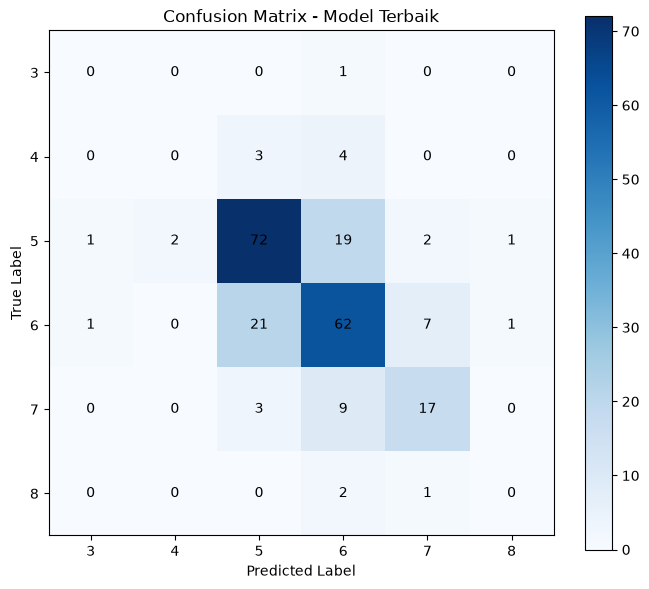

In [29]:
# Tampilkan evaluasi model KNN dengan metriks evaluasi yang sesuai dengan tipe masalah klasifikasi

# Evaluasi model terbaik dari eksperimen utama.
best_scaling = best_row["Scaling"]
best_metric = best_row["Metric"]
best_k = int(best_row["k"])

if best_scaling == "StandardScaler":
    Xtr_best = X_train_scaled
    Xte_best = X_test_scaled
else:
    Xtr_best = X_train.values
    Xte_best = X_test.values

best_p = 1 if best_metric == "Manhattan" else 2

best_knn = KNeighborsClassifier(
    n_neighbors=best_k,
    weights="uniform",
    metric="minkowski",
    p=best_p
)
best_knn.fit(Xtr_best, y_train)

pred_test_best = best_knn.predict(Xte_best)

print(f"Model terbaik: k={best_k}, metric={best_metric}, scaling={best_scaling}")
print(f"Accuracy : {accuracy_score(y_test, pred_test_best):.4f}")
print(f"Precision: {precision_score(y_test, pred_test_best, average='weighted', zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, pred_test_best, average='weighted', zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y_test, pred_test_best, average='weighted', zero_division=0):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, pred_test_best, zero_division=0))

cm = confusion_matrix(y_test, pred_test_best, labels=sorted(y.unique()))
plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Model Terbaik")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(len(sorted(y.unique()))), sorted(y.unique()))
plt.yticks(range(len(sorted(y.unique()))), sorted(y.unique()))

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()


# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen model KNN yang telah dilakukan. Bandingkan hasil antar eksperimen yang telah dilakukan. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.  



Berdasarkan hasil eksperimen, penggunaan **StandardScaler** memberikan hasil yang lebih baik dibandingkan tanpa scaling. Contohnya, pada metric Manhattan dengan `k=1`, akurasi meningkat dari **0.5459** menjadi **0.6594**. Hal ini menunjukkan bahwa scaling penting pada KNN karena KNN menggunakan jarak untuk menentukan tetangga terdekat.

Dari beberapa nilai `k` yang diuji, hasil terbaik diperoleh pada **`k=1` dengan metric Manhattan dan StandardScaler**, dengan Accuracy **0.6594** dan F1-score **0.6517**. Namun, Train Accuracy mencapai **1.0000**, sedangkan Test Accuracy hanya **0.6594**, sehingga terdapat indikasi **overfitting**. Hal ini sesuai dengan materi bahwa nilai `k` yang terlalu kecil dapat menyebabkan overfitting.

Eksperimen tanpa outlier juga dilakukan. Hasil terbaiknya memiliki Accuracy **0.6507** dan F1-score **0.6305**, sehingga masih lebih rendah dibandingkan eksperimen utama. Jadi, pada dataset ini, menghapus outlier belum memberikan hasil yang lebih baik.

Secara keseluruhan, konfigurasi **StandardScaler + Manhattan + `k=1`** memberikan hasil terbaik dari eksperimen yang dilakukan.



# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

KNN dapat digunakan untuk mengklasifikasikan `quality` pada dataset WineQT. Dari percobaan beberapa nilai `k` dan metric jarak, hasil terbaik diperoleh dengan **StandardScaler, metric Manhattan, dan `k=1`**.

Model tersebut menghasilkan **Accuracy 0.6594** dan **F1-score 0.6517**. Namun, terdapat indikasi overfitting karena Train Accuracy mencapai **1.0000**.

Untuk percobaan selanjutnya, dapat mencoba nilai `k` yang lebih banyak agar mendapatkan model yang lebih stabil. Selain itu, dapat menggunakan **cross-validation** dan **macro F1-score** untuk mengevaluasi performa model dengan lebih baik.

